# Robot Arm Sketch-Matched Simulator
- Motor 0: rotates around the **fixed base-j1 vertical axis**
- If motors 1, 2, 3 are all **90 deg**, all arm links stand parallel to **+Z**
- Motors 1, 2, 3 are **relative accumulated angles** to the previous link
- Motor 4: **horizontal wrist swing** (relative), **left=180, right=0**
- Motor 5: gripper, **closed=180, open=0**
- Max gripper opening: **100 mm**
- 3D view uses equal X/Y/Z scale
- Link lengths: base-j1 8.4cm, then 8.4cm, 8.4cm, 19cm (+4cm tool)

In [ ]:
import numpy as np
import cv2
import imageio
import plotly.graph_objects as go
from pathlib import Path
from IPython.display import Image as IPyImage, display

LINKS_M = np.array([0.084, 0.084, 0.084, 0.190, 0.040], dtype=np.float64)
SERVO_MIN = np.zeros(6, dtype=np.float64)
SERVO_MAX = np.full(6, 180.0, dtype=np.float64)
HOME_DEG = np.array([90, 90, 90, 90, 90, 0], dtype=np.float64)
BASE_MM = np.array([0.0, 0.0, 0.0], dtype=np.float64)


def clamp_servo_deg(angles_deg: np.ndarray) -> np.ndarray:
    return np.clip(np.asarray(angles_deg, dtype=np.float64), SERVO_MIN, SERVO_MAX)


def gripper_open_mm(gripper_deg: float) -> float:
    close_ratio = np.clip(gripper_deg / 180.0, 0.0, 1.0)
    return 100.0 * (1.0 - close_ratio)


def fk(angles_deg: np.ndarray, base_mm: np.ndarray):
    a = clamp_servo_deg(angles_deg)

    base_yaw = np.deg2rad(180.0 - a[0])
    p1 = np.deg2rad(90.0 - a[1])
    p2 = np.deg2rad(90.0 - a[2])
    p3 = np.deg2rad(90.0 - a[3])
    wrist_yaw = np.deg2rad(a[4] - 90.0)

    theta1 = p1
    theta2 = p1 + p2
    theta3 = p1 + p2 + p3
    origin = base_mm.astype(np.float64) / 1000.0

    pts_local = [np.array([0.0, 0.0, 0.0], dtype=np.float64)]
    x, z = 0.0, LINKS_M[0]
    pts_local.append(np.array([x, 0.0, z], dtype=np.float64))
    for L, th in zip(LINKS_M[1:4], [theta1, theta2, theta3]):
        x += L * np.sin(th)
        z += L * np.cos(th)
        pts_local.append(np.array([x, 0.0, z], dtype=np.float64))

    # Horizontal wrist swing: yaws tool direction without vertical roll behavior
    tool_dir = np.array([
        np.sin(theta3) * np.cos(wrist_yaw),
        np.sin(wrist_yaw),
        np.cos(theta3),
    ], dtype=np.float64)
    tcp_local = pts_local[-1] + LINKS_M[4] * tool_dir
    pts_local.append(tcp_local)

    c, s = np.cos(base_yaw), np.sin(base_yaw)
    rz = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=np.float64)
    pts_world = np.asarray([origin + rz @ p for p in pts_local], dtype=np.float64)

    grip_width_m = gripper_open_mm(a[5]) / 1000.0
    side_dir_local = np.array([0.0, 1.0, 0.0], dtype=np.float64)
    finger_center = tcp_local - 0.012 * tool_dir
    finger_a = finger_center + 0.5 * grip_width_m * side_dir_local
    finger_b = finger_center - 0.5 * grip_width_m * side_dir_local
    fingers_world = np.asarray([origin + rz @ finger_a, origin + rz @ finger_b], dtype=np.float64)

    return pts_world, fingers_world

Motor angles [0..5] = [ 60.  60.  60.  60.  90. 180.]
Motor 0: rotates around the fixed base-j1 vertical axis
Motors 1,2,3: relative accumulated angles to previous link
If motors 1,2,3 are all 90 deg, links stand parallel to +Z
Motor 4: left=180, right=0
Motor 5: gripper closed=180, open=0
Gripper opening (mm) = 0.0


Saved GIF: /home/nvidia/Desktop/realsense_n_lidar/captures_3d/robot_arm_sim.gif


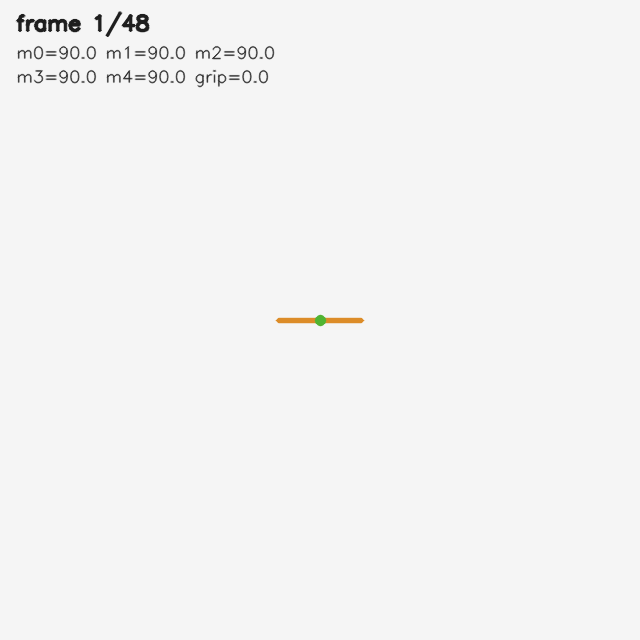

In [ ]:
# Set your motor angles (0..5) here, each in 0~180 deg
MOTOR_DEG = np.array([60, 60, 60, 60, 90, 180], dtype=np.float64)

MOTOR_DEG = clamp_servo_deg(MOTOR_DEG)
print('Motor angles [0..5] =', MOTOR_DEG)
print('Motor 0: rotates around the fixed base-j1 vertical axis')
print('Motors 1,2,3: relative accumulated angles to previous link')
print('If motors 1,2,3 are all 90 deg, links stand parallel to +Z')
print('Motor 4: horizontal wrist swing (left=180, right=0)')
print('Motor 5: gripper closed=180, open=0')
print('Gripper opening (mm) =', round(gripper_open_mm(MOTOR_DEG[5]), 2))

N = 48
traj = np.linspace(HOME_DEG, MOTOR_DEG, N)
traj_pose = [fk(a, BASE_MM) for a in traj]
traj_pts = [pose[0] * 1000.0 for pose in traj_pose]
traj_fingers = [pose[1] * 1000.0 for pose in traj_pose]
final_pts = traj_pts[-1]
final_fingers = traj_fingers[-1]

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=traj_pts[0][:,0], y=traj_pts[0][:,2], z=traj_pts[0][:,1], mode='lines+markers', name='home', line={'width':5, 'color':'rgb(80,130,255)'}))
fig.add_trace(go.Scatter3d(x=final_pts[:,0], y=final_pts[:,2], z=final_pts[:,1], mode='lines+markers+text', name='target pose', text=['base','j1','j2','j3','tool base','tcp'], textposition='top center', line={'width':6, 'color':'rgb(70,200,100)'}))
fig.add_trace(go.Scatter3d(x=final_fingers[:,0], y=final_fingers[:,2], z=final_fingers[:,1], mode='lines+markers', name='gripper width', line={'width':8, 'color':'rgb(220,120,40)'}))
tcp_path = np.asarray([p[-1] for p in traj_pts])
fig.add_trace(go.Scatter3d(x=tcp_path[:,0], y=tcp_path[:,2], z=tcp_path[:,1], mode='lines', name='tcp path', line={'width':4, 'dash':'dash', 'color':'rgb(190,60,220)'}))
fig.update_layout(
    title='Robot Arm Simulator with Relative Accumulated Angles',
    scene={
        'xaxis_title': 'X (mm)',
        'yaxis_title': 'Z (mm)',
        'zaxis_title': 'Y (mm)',
        'xaxis': {'autorange': 'reversed'},
        'aspectmode': 'data'
    },
    height=760
)
fig.show()

gif_path = Path.cwd() / 'captures_3d' / 'robot_arm_sim.gif'
gif_path.parent.mkdir(parents=True, exist_ok=True)
frames = []
for i, (pts, fingers) in enumerate(zip(traj_pts, traj_fingers), start=1):
    canvas = np.full((640, 640, 3), 245, dtype=np.uint8)
    xy = pts[:, :2]
    x_min, x_max = -350.0, 350.0
    y_min, y_max = -350.0, 350.0

    def to_px(pxy):
        u = int((pxy[0] - x_min) / (x_max - x_min) * 580 + 30)
        v = int((1.0 - (pxy[1] - y_min) / (y_max - y_min)) * 580 + 30)
        return (u, v)

    pix = [to_px(p) for p in xy]
    for j in range(len(pix) - 1):
        cv2.line(canvas, pix[j], pix[j+1], (60,130,255), max(2, 8-j), cv2.LINE_AA)
        cv2.circle(canvas, pix[j], 4, (20,20,20), -1, cv2.LINE_AA)
    finger_pix = [to_px(p[:2]) for p in fingers]
    cv2.line(canvas, finger_pix[0], finger_pix[1], (40,140,220), 4, cv2.LINE_AA)
    cv2.circle(canvas, pix[-1], 6, (50,180,80), -1, cv2.LINE_AA)
    cv2.putText(canvas, f'frame {i}/{N}', (16, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (30,30,30), 2, cv2.LINE_AA)
    cv2.putText(canvas, f'm0={traj[i-1,0]:.1f} m1={traj[i-1,1]:.1f} m2={traj[i-1,2]:.1f}', (16, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (40,40,40), 1, cv2.LINE_AA)
    cv2.putText(canvas, f'm3={traj[i-1,3]:.1f} m4={traj[i-1,4]:.1f} grip={traj[i-1,5]:.1f}', (16, 82), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (40,40,40), 1, cv2.LINE_AA)
    frames.append(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))

imageio.mimsave(gif_path, frames, duration=0.03)
display(IPyImage(filename=str(gif_path)))
print('Saved GIF:', gif_path)